## Forest Data Exploration and Cleaning

### Import all Relevant Libraries

In [1]:
import os
from dotenv import load_dotenv

import psycopg2 as pg
from sqlalchemy import create_engine, inspect

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Connection to The Database

In [2]:
load_dotenv()

DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_NAME = os.getenv("DB_NAME")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")

# Connection string
conn_str = f'postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}'

# Connect to the Database
engine = create_engine(conn_str)

In [3]:
# Display all tables in the database with its respective column names

# Create Inspect object
inspector = inspect(engine)

# Get all table names
table_names = inspector.get_table_names()

print("TABLE NAMES")
print("-"*30)

for table in table_names:
    print(table)

print("\n")
print("COLUMN NAMES")
print("-"*30)


# Get all column names of the respective table
for table_name in table_names:
    columns = inspector.get_columns(table_name)
    names = [column['name'] for column in columns]
    print(f"{table_name} columns:\n{names}\n\n")

TABLE NAMES
------------------------------
block_register
plot_monitoring_history
psps
slope_correction_factors
thinning_history
tree_data
plot_bloc_relation


COLUMN NAMES
------------------------------
block_register columns:
['plantation', 'block', 'status', 'rotation', 'ownership', 'reserve', 'year planted', 'block area (ha)', 'productive', 'unproductive', 'Teak', 'NATURAL INDIGENOUS', 'PLANTED INDIGENOUS', 'GMELINA', 'OPEN LAND', 'ROCK', 'remarks']


plot_monitoring_history columns:
['MonitoringID', 'plantation', 'plot', 'area_type', 'monitoring year', 'monitoring Month', 'monitoring day', 'Default plot size', 'plot type', 'Monitoring team', 'Shrub cover (%)', 'Herb cover (%)', 'Invasive species cover (%)', 'Erosion', 'Remarks', 'Excluded', 'Justification for exclusion', 'MDate']


psps columns:
['ID', 'plantation', 'reserve', 'plot', 'Coord_X', 'Coord_Y', 'Provenance', 'Initial N/ha', 'Soil depth', 'Soil inclination (degrees)', 'Lost plot', 'remarks', 'Slope']


slope_correction_

### Retrieve the respective information from the database

In [4]:
# Query the Database to retrieve the relevant data from the respective tables
query = """
    SELECT 
        b.plantation,
        p.block,
        b."year planted",
        b."block area (ha)",
        p.plot,
        pmh."Default plot size",
        pmh."plot type",
        d.area_type,
        d."monitoring year",
        d.tree_id,
        d."Tree SPECIES",
        d.height_m,
        d.dbh_cm,
        d.remarks
    FROM block_register b
    JOIN plot_bloc_relation p
        ON b.plantation = p.plantation
        AND b.block = p.block
    JOIN plot_monitoring_history pmh
        ON pmh.plantation = p.plantation
        AND pmh.plot = p.plot
    JOIN tree_data d
        ON b.plantation = d.plantation
        AND d.plot = p.plot
    WHERE d.area_type = 'Teak';
    
"""

# Import the collected data into Pandas DataFrame
df = pd.read_sql_query(query, engine)

# View the first 5 rows to the dataset
df.head()

,plantation,block,year planted,block area (ha),plot,Default plot size,plot type,area_type,monitoring year,tree_id,Tree SPECIES,height_m,dbh_cm,remarks
0,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars
1,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars
2,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars
3,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars
4,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars


### Exploring the Data set

In [5]:
# The shape of the data. The number of columns and rows in the dataset
df.shape

(2144445, 14)

In [6]:
# The information of the data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2144445 entries, 0 to 2144444
Data columns (total 14 columns):
 #   Column             Dtype  
---  ------             -----  
 0   plantation         str    
 1   block              str    
 2   year planted       int64  
 3   block area (ha)    float64
 4   plot               str    
 5   Default plot size  float64
 6   plot type          str    
 7   area_type          str    
 8   monitoring year    float64
 9   tree_id            float64
 10  Tree SPECIES       str    
 11  height_m           float64
 12  dbh_cm             float64
 13  remarks            str    
dtypes: float64(6), int64(1), str(7)
memory usage: 229.1 MB


In [7]:
# Check for null values in the dataset
df.isna().sum()

plantation                 0
block                      0
year planted               0
block area (ha)            0
plot                       0
Default plot size          0
plot type                  0
area_type                  0
monitoring year            0
tree_id                   18
Tree SPECIES             386
height_m                1197
dbh_cm                  2851
remarks              1840010
dtype: int64

### Data Cleaning

In [8]:
# Remove all null values in the height and dbh
df.dropna(subset=['height_m', 'dbh_cm'], inplace=True)

In [9]:
# Verify if the null values removed for the height and dbh
df.isna().sum()

plantation                 0
block                      0
year planted               0
block area (ha)            0
plot                       0
Default plot size          0
plot type                  0
area_type                  0
monitoring year            0
tree_id                    0
Tree SPECIES             367
height_m                   0
dbh_cm                     0
remarks              1838171
dtype: int64

In [10]:
# Count zero values in height and dbh
print(f"Height: {df['height_m'].eq(0).sum()}")

print(f"DBH: {(df['dbh_cm'] == 0).sum()}")

Height: 720
DBH: 141590


In [11]:
# Remove the zero height and zero dbh from the dataset
df = df[~((df['height_m'] == 0) | (df['dbh_cm'] == 0))]


In [12]:
# Verify
print(f"Height: {df['height_m'].eq(0).sum()}")
print(f"DBH: {df['dbh_cm'].eq(0).sum()}")

Height: 0
DBH: 0


In [13]:
# Review the remarks column to check if there are values that need to be removed
df['remarks'].unique()

<StringArray>
[                        'Fire scars',                                  nan,
                 'Beetle infestation',                         'Top broken',
                         'Broken top',                         'Fork at 2m',
                            '2 stems',                            'Coppice',
                           'Wildling',   'Outside planting line - Wildling',
 ...
 'Abnormal tree, correct measurement',                         'Under tree',
                            'crooked',                       'Under a tree',
                      'Abnormal tree',                            'Crooked',
                           'Abnormal',                               'DEAD',
                       'Abnomal tree',                              ' dead']
Length: 308, dtype: str

In [14]:
# List of unwanted remarks
unwanted = r"(Beetle infestation|Broken top|Wildling|Abnormal tree|Abnormal tree|Abnormal|Top broken|Coppice|DEAD|dead|Outside planting line - Wildling)"

# Remove the unwanted values
unwanted_str = df['remarks'].str.contains(unwanted, case=False, na=False)

df = df[~unwanted_str]

/tmp/ipykernel_9795/523754623.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  unwanted_str = df['remarks'].str.contains(unwanted, case=False, na=False)


In [15]:
# Verify if they are removed
df['remarks'].unique()

<StringArray>
[                       'Fire scars',                                 nan,
                        'Fork at 2m',                           '2 stems',
                            'marked',          'bark damaged by termites',
            'Has leaves to about 6m', 'Black ant attack from base to top',
      'leaves eaten by grasshoppers',                    'Old teak stand',
 ...
                      'under a tree',                           'Climber',
                              'tall',                              'fork',
                             'short',                        'Under tree',
                           'crooked',                      'Under a tree',
                           'Crooked',                      'Abnomal tree']
Length: 162, dtype: str

In [16]:
# Further clean in the remarks
unwanted = r"(crooked|Crooked|marked|Old teak stand|fork|Abnomal tree)"

unwanted_str = df['remarks'].str.contains(unwanted, case=False, na=False)

df = df[~unwanted_str]

/tmp/ipykernel_9795/906020324.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  unwanted_str = df['remarks'].str.contains(unwanted, case=False, na=False)


In [17]:
df['remarks'].unique()

<StringArray>
[                                         'Fire scars',
                                                   nan,
                                             '2 stems',
                            'bark damaged by termites',
                              'Has leaves to about 6m',
                   'Black ant attack from base to top',
                        'leaves eaten by grasshoppers',
                                         'Double stem',
 'The tree is highly branched at this height sideways',
                                               'Dying',
 ...
                                             'climber',
                                                'bent',
                                   'towards bumgate 2',
                               'Circumference of 4,7m',
                                        'under a tree',
                                             'Climber',
                                                'tall',
                             

In [18]:
# Check if all the tree species are teak trees 
df['Tree SPECIES'].unique()

<StringArray>
[                       'Teak',                        'York',
                      'onyono',                    'Mahogany',
                           nan,                     'Albizia',
                    'Kyenkyen',                        'Sofo',
                      'Onyina',                      'Cassia',
                        'Wawa',          'Unknown indigenous',
                    'Asanfena',                      'Hontan',
              'Akuakuo-Ninsuo',                       'Okoro',
                 'Nyankyerene',                     'Watapuo',
                   'Akonkodie',                       'Mango',
                 'kwakuanisuo',                      'Hyedua',
                    'Nyamedua',                   'kotrenfro',
               'Awiemfosamina',                       'Ofram',
                    'Konkroma',                     'Cedrela',
             'Khaya ivorensis',       'Albizia adianthifolia',
                        'Kane',          

In [19]:
# Remove all tree species except teak 
df = df[(df['Tree SPECIES'].str.lower() == 'teak')]

In [20]:
# Verify if they are all removed leaving teak trees
df['Tree SPECIES'].unique()

<StringArray>
['Teak']
Length: 1, dtype: str

In [21]:
# Check for abnormal measurements using height-diameter (h/d) ratio
df['hd_ratio'] = (df['height_m'] / df['dbh_cm']) * 100
df.head()

,plantation,block,year planted,block area (ha),plot,Default plot size,plot type,area_type,monitoring year,tree_id,Tree SPECIES,height_m,dbh_cm,remarks,hd_ratio
0,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667
1,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667
2,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667
3,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667
4,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667


In [22]:
# Remove any data point with h/d ratio less than 30
df = df[~(df['hd_ratio'] < 30)]

In [23]:
# Show the current shape of the dataset
df.shape

(1870039, 15)

### Summary Statistics of the Dataset

In [24]:
df.describe()

,year planted,block area (ha),Default plot size,monitoring year,tree_id,height_m,dbh_cm,hd_ratio
count,1.870039e+06,1.870039e+06,1.870039e+06,1.870039e+06,1.870039e+06,1.870039e+06,1.870039e+06,1.870039e+06
mean,2.012263e+03,6.579895e+01,7.441455e+02,2.019129e+03,3.230751e+01,1.018142e+01,1.252948e+01,8.754412e+01
std,3.059481e+00,1.703064e+01,1.145278e+02,3.256607e+00,2.245391e+01,4.413928e+00,6.388601e+00,2.150693e+01
min,2.001000e+03,4.145545e+00,2.000000e+02,2.009000e+03,1.000000e+00,2.000000e-01,1.000000e-01,3.000000e+01
25%,2.010000e+03,5.653444e+01,7.290000e+02,2.017000e+03,1.400000e+01,6.750000e+00,7.500000e+00,7.399103e+01
50%,2.012000e+03,6.444978e+01,8.000000e+02,2.019000e+03,2.800000e+01,1.050000e+01,1.250000e+01,8.450704e+01
75%,2.015000e+03,7.798380e+01,8.000000e+02,2.021000e+03,4.800000e+01,1.350000e+01,1.700000e+01,9.722222e+01
max,2.022000e+03,1.153682e+02,8.000000e+02,2.024000e+03,1.470000e+02,3.725000e+01,5.270000e+01,1.390000e+03


In [25]:
# Give summary statistics for height and diameter and round the values into 4 decimal points
df[['height_m', 'dbh_cm']].describe().apply(lambda s: s.apply(lambda x: f"{x:.4f}"))

,height_m,dbh_cm
count,1870039.0000,1870039.0000
mean,10.1814,12.5295
std,4.4139,6.3886
min,0.2000,0.1000
25%,6.7500,7.5000
50%,10.5000,12.5000
75%,13.5000,17.0000
max,37.2500,52.7000


### Visualize the Data

<Axes: title={'center': 'Height Distribution'}, ylabel='Frequency'>

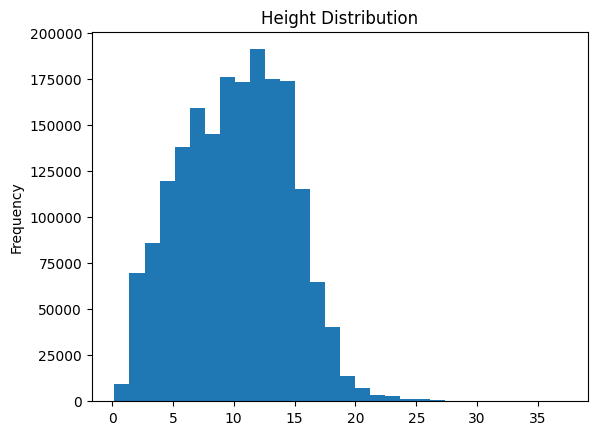

In [26]:
# Height Distribution

df['height_m'].plot.hist(bins=30, title="Height Distribution")

<Axes: title={'center': 'DBH Distribution'}, ylabel='Frequency'>

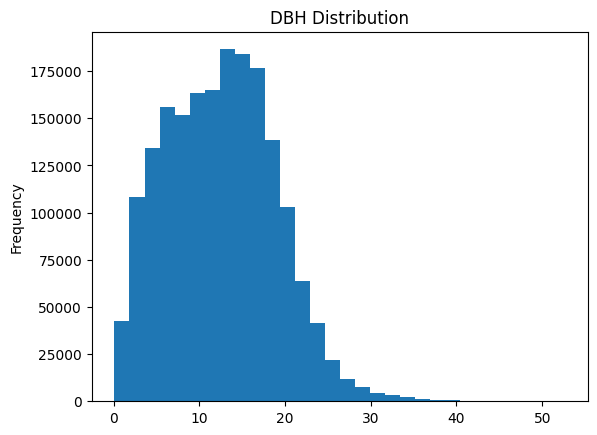

In [27]:
# DBH Distribution
df['dbh_cm'].plot.hist(bins=30, title="DBH Distribution")

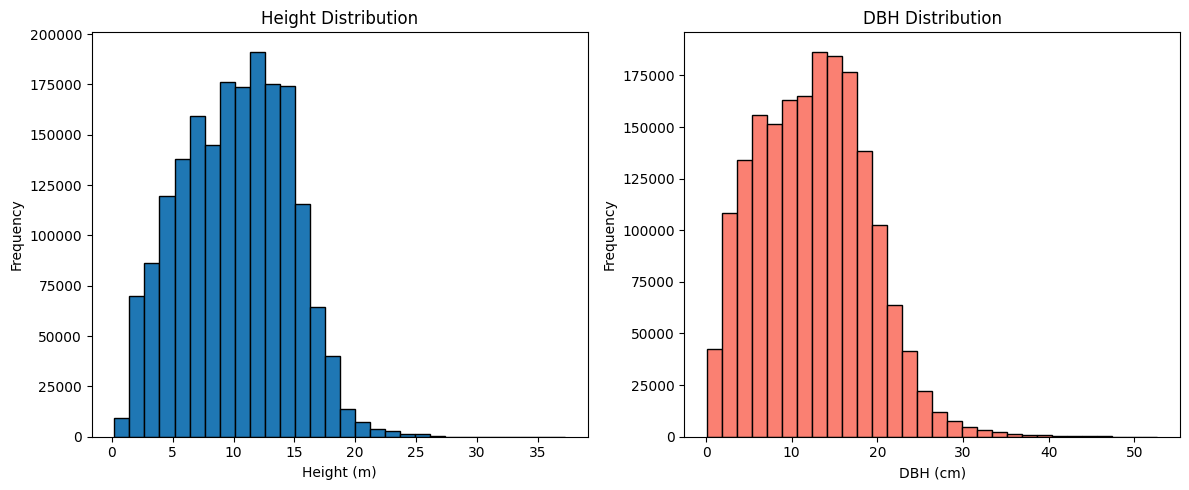

In [29]:
# Using subplotting to display the Height and Diamter Distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

# Plot Height Distribution
ax1.hist(df['height_m'], bins=30, edgecolor='black')
ax1.set_title('Height Distribution')
ax1.set_xlabel('Height (m)')
ax1.set_ylabel('Frequency')

ax2.hist(df['dbh_cm'], bins=30, color='salmon', edgecolor='black')
ax2.set_title('DBH Distribution')
ax2.set_xlabel('DBH (cm)')
ax2.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

<Axes: >

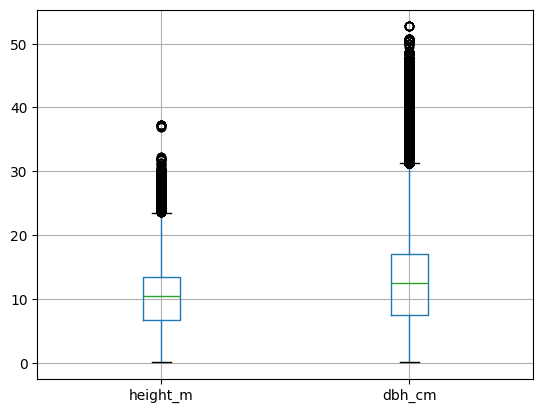

In [30]:
# Height and Diameter Distribution using boxplot
df[['height_m', 'dbh_cm']].boxplot()

### Derived Features

In [31]:
# Compute Tree Age
df['Age'] = df['monitoring year'] - df['year planted']
df.head()

,plantation,block,year planted,block area (ha),plot,Default plot size,plot type,area_type,monitoring year,tree_id,Tree SPECIES,height_m,dbh_cm,remarks,hd_ratio,Age
0,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0
1,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0
2,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0
3,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0
4,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0


In [34]:
# Check for negative age values
neg_age = df[df['Age'] < 0]
neg_age

,plantation,block,year planted,block area (ha),plot,Default plot size,plot type,area_type,monitoring year,tree_id,Tree SPECIES,height_m,dbh_cm,remarks,hd_ratio,Age
1146708,Akumadan,1D,2022,7.153496,633A,800.0,Circular,Teak,2018.0,11.0,Teak,20.50,44.8,NaN,45.758929,-4.0
1146710,Akumadan,1D,2022,7.153496,633A,800.0,Circular,Teak,2018.0,11.0,Teak,20.50,44.8,NaN,45.758929,-4.0
1146712,Akumadan,1D,2022,7.153496,633A,800.0,Circular,Teak,2018.0,11.0,Teak,20.50,44.8,NaN,45.758929,-4.0
1146714,Akumadan,1D,2022,7.153496,633A,800.0,Circular,Teak,2018.0,11.0,Teak,20.50,44.8,NaN,45.758929,-4.0
1146716,Akumadan,1D,2022,7.153496,633A,800.0,Circular,Teak,2018.0,11.0,Teak,20.50,44.8,NaN,45.758929,-4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1645784,Akumadan,1D,2022,7.153496,633A,800.0,Circular,Teak,2021.0,1.0,Teak,23.25,48.6,NaN,47.839506,-1.0
1645786,Akumadan,1D,2022,7.153496,633A,800.0,Circular,Teak,2021.0,1.0,Teak,23.25,48.6,NaN,47.839506,-1.0
1645788,Akumadan,1D,2022,7.153496,633A,800.0,Circular,Teak,2021.0,1.0,Teak,23.25,48.6,NaN,47.839506,-1.0
1645790,Akumadan,1D,2022,7.153496,633A,800.0,Circular,Teak,2021.0,1.0,Teak,23.25,48.6,NaN,47.839506,-1.0


In [35]:
# Remove negative ages from the dataset
df = df[~(df['Age'] < 0)]

In [36]:
check_neg = df[df['Age'] < 0]
check_neg

,plantation,block,year planted,block area (ha),plot,Default plot size,plot type,area_type,monitoring year,tree_id,Tree SPECIES,height_m,dbh_cm,remarks,hd_ratio,Age


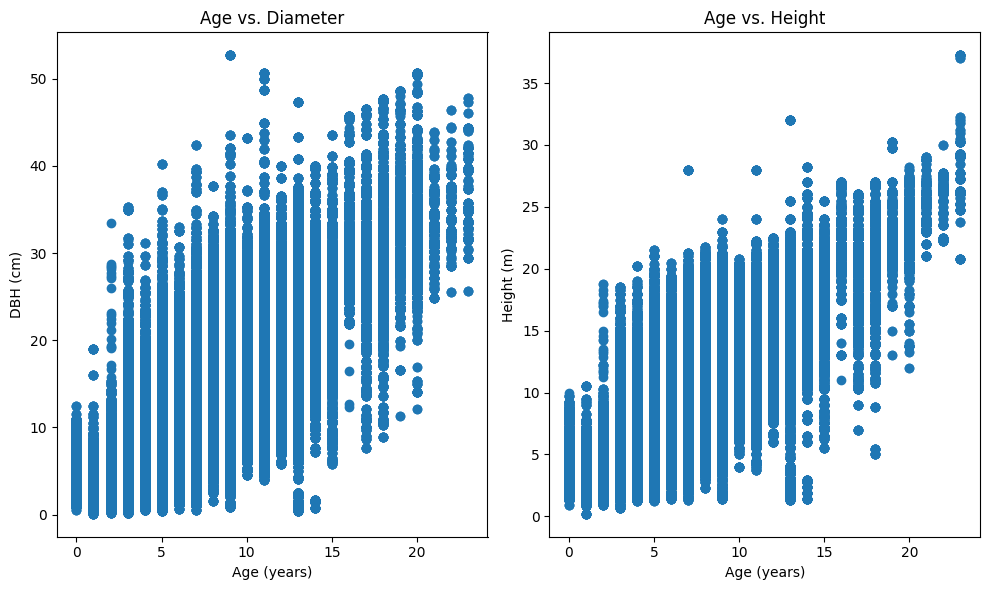

In [37]:
# Age vs Diameter and Height

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,6))

# plot Age vs DBH
ax1.scatter(df['Age'], df['dbh_cm'])
ax1.set_title("Age vs. Diameter")
ax1.set_xlabel('Age (years)')
ax1.set_ylabel('DBH (cm)')

# plot Age vs Height
ax2.scatter(df['Age'], df['height_m'])
ax2.set_title("Age vs. Height")
ax2.set_xlabel('Age (years)')
ax2.set_ylabel('Height (m)')

plt.tight_layout()
plt.show()

In [38]:
# Compute Basal Area
df['basal_area'] = (np.pi*(df['dbh_cm'])**2)/40000

In [39]:
df.head()

,plantation,block,year planted,block area (ha),plot,Default plot size,plot type,area_type,monitoring year,tree_id,Tree SPECIES,height_m,dbh_cm,remarks,hd_ratio,Age,basal_area
0,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0,0.01131
1,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0,0.01131
2,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0,0.01131
3,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0,0.01131
4,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0,0.01131


In [42]:
# Basal Area per Plot per Monitoring year
ba_plot = df.groupby(['plot', 'monitoring year'])['basal_area'].sum().reset_index(name='basal_area_plot')
ba_plot

,plot,monitoring year,basal_area_plot
0,1,2009.0,0.017297
1,1,2010.0,0.046535
2,1,2011.0,0.165397
3,1,2012.0,1.944167
4,1,2013.0,3.019874
...,...,...,...
6019,990,2024.0,5.405798
6020,991,2021.0,1.985345
6021,991,2022.0,1.954237
6022,991,2023.0,2.904701


In [45]:
# Display in a pivot table
pivot_ba = ba_plot.pivot(index='plot', columns='monitoring year', values='basal_area_plot')
pivot_ba

monitoring year,2009.0,2010.0,2011.0,2012.0,2013.0,2014.0,2015.0,2016.0,2017.0,2018.0,2019.0,2020.0,2021.0,2022.0,2023.0,2024.0
plot,,,,,,,,,,,,,,,,
1,0.017297,0.046535,0.165397,1.944167,3.019874,NaN,6.101538,NaN,4.376233,0.814258,8.347436,2.99070,11.782774,6.205608,11.735620,NaN
10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.207440,4.186081,5.04096,6.752236,7.705345,9.986035,NaN
100,NaN,NaN,0.005867,0.044002,0.280066,NaN,2.233282,NaN,4.152596,7.661259,7.899216,NaN,10.179692,NaN,13.267267,NaN
101,NaN,NaN,NaN,0.049318,0.179542,NaN,1.256041,NaN,2.743929,4.912516,4.576269,NaN,7.282612,NaN,9.852716,NaN
102,NaN,NaN,NaN,0.015280,0.134317,NaN,1.785692,NaN,8.477307,7.162179,6.465203,NaN,8.936988,NaN,11.855838,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
988,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.119529,NaN,1.745196,NaN
989,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.467709,NaN,0.999919,NaN
99,NaN,NaN,NaN,0.129256,1.131668,NaN,4.178683,NaN,6.486565,9.233428,8.043968,NaN,10.345333,NaN,13.489900,NaN


Text(0.5, 1.0, 'Basal Area Trajectory in Plot 1')

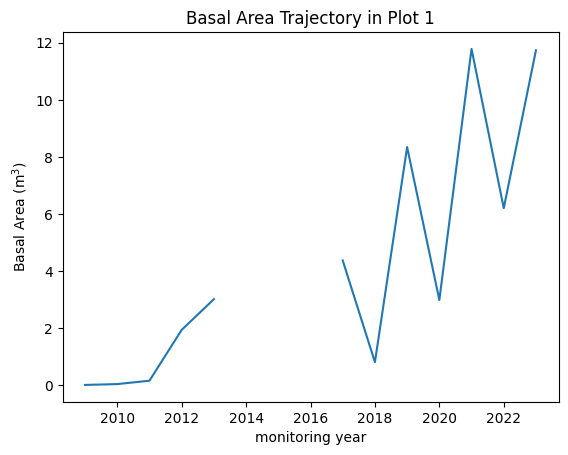

In [50]:
# Visualizing the basal area for plot 1
pivot_ba.iloc[0].plot(kind='line')
plt.ylabel('Basal Area (m$^3$)')
plt.title('Basal Area Trajectory in Plot 1')

In [51]:
# Basal Area per Hectare

# Convert plot size from meter squared to hectare
df['plot_size_ha'] = df['Default plot size'] / 10000

# calculate tree expansion factor
df['expansion_factor'] = 1 / df['plot_size_ha']

df['ba_ha'] = df['basal_area'] * df['expansion_factor']

df.head()

,plantation,block,year planted,block area (ha),plot,Default plot size,plot type,area_type,monitoring year,tree_id,Tree SPECIES,height_m,dbh_cm,remarks,hd_ratio,Age,basal_area,plot_size_ha,expansion_factor,ba_ha
0,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0,0.01131,0.0729,13.717421,0.15514
1,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0,0.01131,0.0729,13.717421,0.15514
2,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0,0.01131,0.0729,13.717421,0.15514
3,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0,0.01131,0.0729,13.717421,0.15514
4,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0,0.01131,0.0729,13.717421,0.15514


In [52]:
# Basal Area per hectare per plot
ba_ha_plot = df.groupby(['monitoring year', 'plot'])['ba_ha'].sum().reset_index(name='ba_ha_plot')
ba_ha_plot

,monitoring year,plot,ba_ha_plot
0,2009.0,1,0.410803
1,2009.0,11,95.035420
2,2009.0,12,123.171627
3,2009.0,13,37.731061
4,2009.0,14,107.444507
...,...,...,...
6019,2024.0,816,29.171455
6020,2024.0,819,47.484388
6021,2024.0,978,47.772635
6022,2024.0,990,74.153610


In [53]:
ba_ha_blk = df.groupby(['monitoring year', 'block'])['ba_ha'].sum().reset_index(name='ba_ha_blk')
ba_ha_blk

,monitoring year,block,ba_ha_blk
0,2009.0,1A,516.271455
1,2009.0,2A,7.291386
2,2009.0,3A,3.837101
3,2010.0,10,1.038353
4,2010.0,1A,323.661454
...,...,...,...
921,2024.0,B46,372.381327
922,2024.0,B64,951.563969
923,2024.0,B8,300.283230
924,2024.0,B9A,396.767250


In [55]:
# Stand Density
num_plots = df['plot'].nunique()
stand_tph = df['expansion_factor'].sum() / num_plots
stand_tph

np.float64(22946.994050738154)